# Stage 3 -- Hungarian assignment ablation (M, 8 drones, freeze-first)

**2026-09-30.** Follow-up to `code/notebooks/v3/stage2/ablation-hungarian/`
(the same ablation at Stage 2, 5 drones) -- Manish's point: the actual live
question is why Stage 3 underperforms DA-MAPPO (`bin/91`) despite fewer
obstacles (`docs/research/07_literature_comparison.md`), and one hypothesis
there was that **more drones sharing the same space (8, vs DA-MAPPO's 3)
makes assignment quality matter more, not less**. That can only be tested
at Stage 3, not Stage 2 -- this notebook is the direct test.

**Same ablation mechanism as the Stage 2 version** (`use_hungarian=False`:
assignment fixed once at `reset()`, never re-solved, even though targets
keep moving) -- ported onto this exact Stage 3 setup: 8 drones, 10
obstacles, freeze-first critic warm-start (actor+PAH frozen for the first
`freeze_episodes`, only the critic trains -- see `stage3/var-alpha`'s Cell
0 for why), disjoint eval seed (999, never a training seed).

**Reference points already in hand:**
- Stage 1 ablation (3 drones, no PAH/obstacles): ON 100%/0%, OFF 96.3%/3.6%
  avg, 54% of checkpoints had collisions (`code/notebooks/v3/stage1/
  v3-with-or-without-hungarian-ablation-result-comparison/report.md`)
- Stage 2 ablation (5 drones, PAH): result pending
- Stage 2 Hungarian ON (ADOPTED): 90.9%/9.1% avg
- Stage 3 Hungarian ON (ADOPTED): 74.8%/25.2% avg, single seed
  (`sessions/2026-09-19.md` Section 11)
- DA-MAPPO's own ablation (`bin/91`, Table VI): success collapses to 0%

**If Stage 3's OFF result degrades much more sharply than Stage 2's OFF
result did (relative to each one's own ON baseline), that supports the
"more drones -> assignment matters more" hypothesis** and would be a
genuinely useful, specific finding for the thesis -- not just "assignment
matters," but *how much it matters scales with swarm size*, which nobody
in the reference papers tested directly (DA-MAPPO only tested N=3).

**Scope for this run: seed 42 only** (~1h with freeze-first), same
discipline as every other new mechanism this cycle.


In [1]:
# Cell 1 — Imports
import torch
import numpy as np
from scipy.optimize import linear_sum_assignment
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {DEVICE}')

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda


In [2]:
# Cell 2 — Conflict Graph
# Ported from code/algorithms/conflict_graph.py

import numpy as np

def _time_to_cpa(pos_i, pos_j, vel_i, vel_j):
    p = pos_i - pos_j
    v = vel_i - vel_j
    vv = np.dot(v, v)
    if vv < 1e-8:
        return np.inf
    return -np.dot(p, v) / vv

def _dist_at_cpa(pos_i, pos_j, vel_i, vel_j, horizon):
    p = pos_i - pos_j
    v = vel_i - vel_j
    vv = np.dot(v, v)
    if vv < 1e-8:
        return float(np.linalg.norm(p)), 0.0
    t_star = -np.dot(p, v) / vv
    t_clamped = float(np.clip(t_star, 0.0, horizon))
    return float(np.linalg.norm(p + v * t_clamped)), t_star

class ConflictGraph:
    K_NBR = 4

    def __init__(self, n_drones, horizon=3.0, d_danger=9.0):
        self.n      = n_drones
        self.H      = horizon
        self.d_dan  = d_danger
        self.adj    = np.zeros((n_drones, n_drones), dtype=bool)
        self.t_mat  = np.full((n_drones, n_drones), np.inf)

    def update(self, pos, vel):
        self.adj[:] = False
        self.t_mat[:] = np.inf
        for i in range(self.n):
            for j in range(i + 1, self.n):
                dcpa, t_star = _dist_at_cpa(pos[i], pos[j], vel[i], vel[j], self.H)
                self.t_mat[i, j] = self.t_mat[j, i] = t_star
                if dcpa < self.d_dan and 0.0 <= t_star <= self.H:
                    self.adj[i, j] = self.adj[j, i] = True

    def n_conflict(self, i):
        return int(self.adj[i].sum())

    def tau_collision(self, i):
        nbrs = np.where(self.adj[i])[0]
        if len(nbrs) == 0:
            return self.H
        return float(np.min(self.t_mat[i, nbrs]))

    def neighbor_obs(self, i, pos, vel):
        obs = np.zeros(self.K_NBR * 5, dtype=np.float32)
        nbrs = np.where(self.adj[i])[0]
        if len(nbrs) == 0:
            return obs
        order = np.argsort(self.t_mat[i, nbrs])
        nbrs  = nbrs[order]
        for slot, j in enumerate(nbrs[:self.K_NBR]):
            b = slot * 5
            obs[b:b+2]   = pos[j] - pos[i]
            obs[b+2:b+4] = vel[j] - vel[i]
            obs[b+4]     = 1.0
        return obs

In [3]:
# Cell 3 -- Environment (Stage 3 base + Hungarian-assignment ablation switch)
#
# Same ablation switch as code/notebooks/v3/stage2/ablation-hungarian/ --
# ported here identically since Stage 2 and Stage 3's environment code is
# byte-identical (only CFG values like n_drones/n_obstacles differ). See
# Cell 0 for why this needs testing at Stage 3 specifically, not just
# Stage 2.

import numpy as np
from scipy.optimize import linear_sum_assignment

K_NBR    = 4
BASE_DIM = 10
OBS_DIM  = BASE_DIM + K_NBR * 5  # 30

class MultiUAVEnv:
    def __init__(self, n_drones=5, n_obstacles=5, world_size=500.0,
                 max_speed=5.0, max_steps=500, collision_radius=3.0,
                 target_radius=25.0, success_bonus=20.0,
                 target_speed=1.0, use_hungarian=True, seed=None):
        self.n         = n_drones
        self.n_obs     = n_obstacles
        self.W         = world_size
        self.max_sp    = max_speed
        self.max_steps = max_steps
        self.col_r     = collision_radius
        self.tgt_r     = target_radius
        self.bonus     = success_bonus
        self.tgt_speed = target_speed
        # Ablation switch (see Cell 0): True = per-step optimal Hungarian
        # assignment (normal). False = fixed pairing decided once at
        # reset(), never re-solved.
        self.use_hungarian = use_hungarian
        self.rng       = np.random.default_rng(seed)
        self.cg        = ConflictGraph(n_drones, horizon=3.0,
                                       d_danger=collision_radius * 3.0)
        self.obs_dim   = OBS_DIM
        self.act_dim   = 2

    def reset(self):
        self.t                  = 0
        self.collision_occurred = False
        all_pos = self._sample_non_overlapping(self.n * 2, self.col_r * 2)
        self.drone_pos  = all_pos[:self.n].copy()
        self.target_pos = all_pos[self.n:].copy()
        self.obstacle_pos = self._place_obstacles(
            np.concatenate([self.drone_pos, self.target_pos]), self.n_obs
        )
        self.drone_vel = np.zeros((self.n, 2), dtype=np.float32)
        angles = self.rng.uniform(0, 2 * np.pi, self.n)
        self.target_vel = (self.tgt_speed * np.stack(
            [np.cos(angles), np.sin(angles)], axis=1
        )).astype(np.float32)
        # Ablation: fixed pairing (arbitrary) when Hungarian is off -- never
        # re-solved, even though targets keep moving. See Cell 0.
        self.assignment = self._hungarian() if self.use_hungarian else np.arange(self.n)
        self.cg.update(self.drone_pos, self.drone_vel)
        return self._obs()

    def step(self, actions):
        self.t += 1
        actions = np.clip(actions, -self.max_sp, self.max_sp)
        self.drone_vel = actions.astype(np.float32)
        self.drone_pos = np.clip(self.drone_pos + self.drone_vel, 0.0, self.W)

        self.target_pos = self.target_pos + self.target_vel
        for k in range(self.n):
            for dim in range(2):
                if self.target_pos[k, dim] < 10.0:
                    self.target_pos[k, dim] = 10.0
                    self.target_vel[k, dim] *= -1.0
                elif self.target_pos[k, dim] > self.W - 10.0:
                    self.target_pos[k, dim] = self.W - 10.0
                    self.target_vel[k, dim] *= -1.0

        # Ablation: keep the reset()-time assignment fixed when Hungarian is
        # off -- re-solved every step only in the normal (True) case.
        if self.use_hungarian:
            self.assignment = self._hungarian()
        self.cg.update(self.drone_pos, self.drone_vel)

        rewards, r_mission, r_safety = self._rewards()
        all_reached   = self._all_reached()
        any_collision = self._any_collision()
        timeout       = self.t >= self.max_steps

        if any_collision:
            self.collision_occurred = True

        terminated = all_reached or any_collision
        truncated  = timeout

        if all_reached and self.bonus:
            rewards   = rewards + self.bonus
            r_mission = r_mission + self.bonus   # bonus is a mission outcome, not safety

        # PAH inputs — per drone, from the conflict graph + current assignment.
        pah_inputs = {
            'tau': np.array([self.cg.tau_collision(i) for i in range(self.n)], dtype=np.float32),
            'd_target': np.array([
                np.linalg.norm(self.drone_pos[i] - self.target_pos[self.assignment[i]])
                for i in range(self.n)
            ], dtype=np.float32),
            'n_conflict': np.array([self.cg.n_conflict(i) for i in range(self.n)], dtype=np.float32),
        }

        info = {
            'all_targets_reached': all_reached,
            'any_collision':       any_collision,
            'episode_collision':   self.collision_occurred,
            'r_mission':           r_mission,
            'r_safety':            r_safety,
            'pah_inputs':          pah_inputs,
        }
        return self._obs(), rewards, terminated, truncated, info

    def _obs(self):
        obs = np.zeros((self.n, self.obs_dim), dtype=np.float32)
        for i in range(self.n):
            rel = self.target_pos[self.assignment[i]] - self.drone_pos[i]
            cl  = self._clearances(i)
            base = np.concatenate([
                self.drone_pos[i] / self.W,
                self.drone_vel[i] / self.max_sp,
                rel               / self.W,
                cl,
            ])
            nbr = self.cg.neighbor_obs(i, self.drone_pos, self.drone_vel)
            for s in range(K_NBR):
                nbr[s*5 : s*5+2]   /= self.W
                nbr[s*5+2 : s*5+4] /= self.max_sp
            obs[i] = np.concatenate([base, nbr])
        return obs

    def _rewards(self):
        r_mission = np.zeros(self.n, dtype=np.float32)
        r_safety  = np.zeros(self.n, dtype=np.float32)
        d_danger  = self.col_r * 3.0
        zone_w    = d_danger - self.col_r
        for i in range(self.n):
            rel  = self.target_pos[self.assignment[i]] - self.drone_pos[i]
            dist = np.linalg.norm(rel)
            direction  = rel / (dist + 1e-6)
            r_progress = float(np.dot(self.drone_vel[i], direction) / self.max_sp)
            r_mission[i] = 0.4 * r_progress + 0.3 * (-dist / self.W)
            min_d = float('inf')
            for j in range(self.n):
                if j != i:
                    min_d = min(min_d, np.linalg.norm(self.drone_pos[i] - self.drone_pos[j]))
            for op in self.obstacle_pos:
                min_d = min(min_d, np.linalg.norm(self.drone_pos[i] - op))
            if min_d < self.col_r:
                r_safety[i] = -1.0
            elif min_d < d_danger:
                r_safety[i] = -((d_danger - min_d) / zone_w)
        rewards = r_mission + 0.3 * r_safety
        return rewards, r_mission, r_safety

    def _hungarian(self):
        cost = np.array([
            [np.linalg.norm(self.drone_pos[i] - self.target_pos[j])
             for j in range(self.n)]
            for i in range(self.n)
        ])
        _, col = linear_sum_assignment(cost)
        return col

    def _all_reached(self):
        return all(
            np.linalg.norm(self.drone_pos[i] - self.target_pos[self.assignment[i]]) <= self.tgt_r
            for i in range(self.n)
        )

    def _any_collision(self):
        for i in range(self.n):
            for j in range(self.n):
                if j != i and np.linalg.norm(self.drone_pos[i] - self.drone_pos[j]) < self.col_r:
                    return True
            for op in self.obstacle_pos:
                if np.linalg.norm(self.drone_pos[i] - op) < self.col_r:
                    return True
        return False

    def _clearances(self, i):
        pos = self.drone_pos[i]
        cl  = np.array([self.W - pos[1], pos[1], self.W - pos[0], pos[0]], dtype=np.float32)
        for op in self.obstacle_pos:
            diff = op - pos
            if diff[1] > 0: cl[0] = min(cl[0],  diff[1])
            else:           cl[1] = min(cl[1], -diff[1])
            if diff[0] > 0: cl[2] = min(cl[2],  diff[0])
            else:           cl[3] = min(cl[3], -diff[0])
        return cl / self.W

    def _sample_non_overlapping(self, n, min_dist):
        pts, attempts = [], 0
        while len(pts) < n:
            attempts += 1
            if attempts > 10000:
                raise RuntimeError('World too crowded.')
            c = self.rng.uniform(10.0, self.W - 10.0, 2)
            if not any(np.linalg.norm(c - p) < min_dist for p in pts):
                pts.append(c)
        return np.array(pts, dtype=np.float32)

    def _place_obstacles(self, existing, n_obs, max_tries=1000):
        if n_obs <= 0:
            return np.zeros((0, 2), dtype=np.float32)
        r_min = 2.0 * self.col_r
        placed = []
        for _ in range(n_obs):
            for _ in range(max_tries):
                c = self.rng.uniform(10.0, self.W - 10.0, 2)
                if any(np.linalg.norm(c - o) < r_min for o in placed): continue
                if any(np.linalg.norm(c - p) < self.col_r for p in existing): continue
                placed.append(c)
                break
            else:
                break
        return np.array(placed, dtype=np.float32) if placed else np.zeros((0, 2), dtype=np.float32)

print('obs_dim = {}  (10 base + {}x5 conflict neighbors, normalized)'.format(OBS_DIM, K_NBR))
print('step() now also returns info["pah_inputs"] = {tau, d_target, n_conflict}')


obs_dim = 30  (10 base + 4x5 conflict neighbors, normalized)
step() now also returns info["pah_inputs"] = {tau, d_target, n_conflict}


In [4]:
# Cell 4 -- MAPPO + PAH (prior + learned residual, single critic) -- Stage 3, 8 drones
#
# ADOPTED design (Ayesha + Manish sign-off, sessions/2026-09-18.md Section
# 22) -- see Cell 0 markdown for Stage 3 context (freeze-first critic
# warm-start, disjoint eval seed). Single-critic architecture, same
# Actor/Critic/RolloutBuffer as Stage 2 (unchanged, proven). PAH is the
# prior+residual design:
#
#   alpha(s) = clip( alpha_safe(tau) + delta_phi(s), alpha_min, alpha_max )
#
# alpha_safe(tau) is the SAME tau-formula stage2-pah-v0/v2 tried to pull
# alpha toward with a prior LOSS -- now it's hardcoded directly into
# forward(), not something the network has to learn or that a loss has to
# win a race for. delta_phi(s) is a small learned correction, bounded via
# tanh to [-delta_scale, +delta_scale], regularized toward zero.
#
# Why this fixes the seed-dependent race/lock-in diagnosed in
# sessions/2026-09-18.md Section 15: previously the WHOLE of alpha came
# from the network, and both the actor loss (pulls alpha up, batch-
# averaged, dominated by common safe states) and the prior loss (pulls
# alpha down, only near danger) fought over that one number before the
# policy's entropy collapsed -- whichever won got locked in, and which one
# won was sensitive to each seed's early rollout trajectory. Now alpha_safe
# is structurally always present; the actor loss can only ever push the
# bounded residual around it, not erase it.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))

    def forward(self, x):
        h       = self.net(x)
        mu      = self.mu_head(h)
        log_std = self.log_std.clamp(-4.0, 1.5)   # safety net, see Stage 2 notes
        std     = log_std.exp().expand_as(mu)
        return Normal(mu, std)

    def get_action(self, obs):
        dist   = self(obs)
        action = dist.sample()
        log_p  = dist.log_prob(action).sum(-1)
        return action, log_p

    def evaluate_action(self, obs, action):
        dist    = self(obs)
        log_p   = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_p, entropy


class Critic(nn.Module):
    """Centralized critic -- one value per timestep from the flattened joint state."""
    def __init__(self, global_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


class PAHNormalizer:
    """Scales the 3 raw PAH inputs to roughly [0,1]. Ported from code/algorithms/pah.py."""
    def __init__(self, horizon=3.0, d_max=707.1, n_drones=5):
        self.horizon  = horizon
        self.d_max    = d_max
        self.n_drones = n_drones

    def normalize(self, tau, d_target, n_conflict):
        tau_norm = tau.clamp(0.0, self.horizon) / self.horizon
        d_norm   = d_target.clamp(0.0, self.d_max) / self.d_max
        denom    = max(self.n_drones - 1, 1)
        n_norm   = n_conflict.clamp(0.0, denom) / denom
        return torch.stack([tau_norm, d_norm, n_norm], dim=-1)


class PriorityArbitrationHead(nn.Module):
    """alpha(s) = clip(alpha_safe(tau) + delta(s), alpha_min, alpha_max).
    alpha_safe is a hardcoded tau-formula (never learned, never lost).
    delta is a small learned correction, tanh-bounded to
    [-delta_scale, +delta_scale], regularized toward zero. See Cell 4
    header for the full rationale."""
    def __init__(self, hidden_dim=32, alpha_min=0.1, alpha_max=0.9,
                 delta_scale=0.2, prior_coef=0.15):
        super().__init__()
        self.alpha_min   = alpha_min
        self.alpha_max   = alpha_max
        self.delta_scale = delta_scale
        self.prior_coef  = prior_coef
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        nn.init.zeros_(self.net[-1].bias)
        nn.init.xavier_uniform_(self.net[-1].weight, gain=0.1)

    def alpha_safe(self, tau_norm):
        return self.alpha_min + (self.alpha_max - self.alpha_min) * tau_norm

    def forward(self, x):
        """x: (..., 3) = [tau_norm, d_norm, n_norm]. Returns (alpha, delta)."""
        tau_norm  = x[..., 0]
        raw_delta = torch.tanh(self.net(x).squeeze(-1))
        delta     = self.delta_scale * raw_delta
        alpha     = (self.alpha_safe(tau_norm) + delta).clamp(self.alpha_min, self.alpha_max)
        return alpha, delta

    def compute_prior_loss(self, delta):
        """Regularizes the residual toward zero -- NOT toward the formula
        (alpha_safe already IS the formula, hardcoded). This only earns a
        role in training if a non-zero delta demonstrably lowers the total
        loss beyond what alpha_safe already gets for free."""
        if self.prior_coef == 0.0:
            return torch.tensor(0.0, device=delta.device)
        return self.prior_coef * delta.pow(2).mean()


class RolloutBuffer:
    """Per-drone rewards/log-probs/PAH-inputs kept separate throughout -- nothing
    here is averaged across drones (see sessions/2026-09-15.md Part 12 for why
    that was a bug in an earlier version of the Stage 2 notebook)."""
    def __init__(self, n_drones):
        self.n_drones = n_drones
        self.clear()

    def clear(self):
        self.obs, self.acts, self.rews = [], [], []
        self.vals, self.lps, self.dones = [], [], []
        self.r_mission, self.r_safety = [], []
        self.tau, self.d_target, self.n_conflict = [], [], []

    def add(self, obs, act, rew, val, lp, done, r_mission, r_safety, pah_inputs):
        self.obs.append(obs.copy())
        self.acts.append(act.copy())
        self.rews.append(rew.copy())
        self.vals.append(float(val))
        self.lps.append(lp.copy())
        self.dones.append(bool(done))
        self.r_mission.append(r_mission.copy())
        self.r_safety.append(r_safety.copy())
        self.tau.append(pah_inputs['tau'].copy())
        self.d_target.append(pah_inputs['d_target'].copy())
        self.n_conflict.append(pah_inputs['n_conflict'].copy())

    def __len__(self):
        return len(self.rews)

    def compute_gae(self, last_val, gamma, lam):
        """Combined-reward GAE -- used for the critic's return target."""
        T = len(self.rews)
        n = self.n_drones
        rewards = np.array(self.rews,  dtype=np.float32)
        values  = np.array(self.vals,  dtype=np.float32)
        dones   = np.array(self.dones, dtype=np.float32)
        adv      = np.zeros((T, n), dtype=np.float32)
        last_gae = np.zeros(n, dtype=np.float32)
        for t in reversed(range(T)):
            next_val = last_val if t == T - 1 else values[t + 1]
            mask     = 1.0 - dones[t]
            delta    = rewards[t] + gamma * next_val * mask - values[t]
            last_gae = delta + gamma * lam * mask * last_gae
            adv[t]   = last_gae
        returns = adv + values[:, np.newaxis]
        return adv, returns

    def compute_gae_components(self, last_val, gamma, lam):
        """Separate GAE for r_mission and r_safety, sharing the combined-reward
        critic as baseline ("Option B lite" -- see docs/research/01_pah_design.md
        Section 9). Used for the alpha-weighted actor loss."""
        T = len(self.rews)
        n = self.n_drones
        rm      = np.array(self.r_mission, dtype=np.float32)
        rs      = np.array(self.r_safety,  dtype=np.float32)
        values  = np.array(self.vals,      dtype=np.float32)
        dones   = np.array(self.dones,     dtype=np.float32)
        adv_m = np.zeros((T, n), dtype=np.float32)
        adv_s = np.zeros((T, n), dtype=np.float32)
        gae_m = np.zeros(n, dtype=np.float32)
        gae_s = np.zeros(n, dtype=np.float32)
        for t in reversed(range(T)):
            next_val = last_val if t == T - 1 else values[t + 1]
            mask     = 1.0 - dones[t]
            delta_m  = rm[t] + gamma * next_val * mask - values[t]
            delta_s  = rs[t] + gamma * next_val * mask - values[t]
            gae_m    = delta_m + gamma * lam * mask * gae_m
            gae_s    = delta_s + gamma * lam * mask * gae_s
            adv_m[t] = gae_m
            adv_s[t] = gae_s
        return adv_m, adv_s


class MAPPOAgent:
    def __init__(self, n_drones, obs_dim, act_dim, use_pah=True, fixed_alpha=0.5,
                 pah_hidden=32, alpha_min=0.1, alpha_max=0.9, pah_delta_scale=0.2,
                 pah_prior_coef=0.15, pah_horizon=3.0, pah_d_max=707.1,
                 lr=3e-4, gamma=0.99, lam=0.95, clip_eps=0.2, vf_coef=0.5,
                 ent_coef=0.003, n_epochs=10, batch_size=64):
        self.n_drones = n_drones
        self.use_pah  = use_pah
        self.fixed_alpha = fixed_alpha
        self.gamma, self.lam           = gamma, lam
        self.clip_eps                  = clip_eps
        self.vf_coef, self.ent_coef    = vf_coef, ent_coef
        self.n_epochs, self.batch_size = n_epochs, batch_size

        global_dim  = n_drones * obs_dim
        self.actor  = Actor(obs_dim, act_dim).to(DEVICE)
        self.critic = Critic(global_dim).to(DEVICE)
        params = list(self.actor.parameters()) + list(self.critic.parameters())

        if use_pah:
            self.pah        = PriorityArbitrationHead(
                pah_hidden, alpha_min, alpha_max, pah_delta_scale, pah_prior_coef
            ).to(DEVICE)
            self.normalizer = PAHNormalizer(pah_horizon, pah_d_max, n_drones)
            params += list(self.pah.parameters())
        else:
            self.pah        = None
            self.normalizer = None

        self.opt = optim.Adam(params, lr=lr)

    @torch.no_grad()
    def get_actions(self, obs):
        obs_t          = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
        action_t, lp_t = self.actor.get_action(obs_t)
        global_state   = obs_t.flatten().unsqueeze(0)
        value          = self.critic(global_state).item()
        return action_t.cpu().numpy(), lp_t.cpu().numpy(), value

    @torch.no_grad()
    def compute_alpha(self, tau_np, d_np, n_np):
        """Inference-time alpha (no gradient) -- used to build the combined
        reward that the environment/buffer stores for the critic target."""
        if not self.use_pah:
            return np.full(self.n_drones, self.fixed_alpha, dtype=np.float32)
        tau = torch.tensor(tau_np, dtype=torch.float32, device=DEVICE)
        d   = torch.tensor(d_np,   dtype=torch.float32, device=DEVICE)
        n   = torch.tensor(n_np,   dtype=torch.float32, device=DEVICE)
        x         = self.normalizer.normalize(tau, d, n)
        alpha, _  = self.pah(x)
        return alpha.cpu().numpy()

    def _alpha_with_grad(self, tau_t, d_t, n_t):
        """Training-time (alpha, delta) with gradient. delta is what
        compute_prior_loss regularizes toward zero -- NOT alpha itself, and
        NOT toward any formula (alpha_safe inside pah.forward already IS
        the formula)."""
        if not self.use_pah:
            alpha = torch.full((tau_t.shape[0],), self.fixed_alpha,
                                dtype=torch.float32, device=DEVICE)
            return alpha, None
        x = self.normalizer.normalize(tau_t, d_t, n_t)
        return self.pah(x)   # (alpha, delta)

    def update(self, buffer, last_obs):
        last_obs_t = torch.tensor(last_obs, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            last_val = self.critic(last_obs_t.flatten().unsqueeze(0)).item()

        adv_np, ret_np       = buffer.compute_gae(last_val, self.gamma, self.lam)
        adv_m_np, adv_s_np   = buffer.compute_gae_components(last_val, self.gamma, self.lam)

        obs_np = np.array(buffer.obs,  dtype=np.float32)   # (T,n,D)
        act_np = np.array(buffer.acts, dtype=np.float32)   # (T,n,2)
        lp_np  = np.array(buffer.lps,  dtype=np.float32)   # (T,n)
        tau_np = np.array(buffer.tau,        dtype=np.float32)  # (T,n)
        d_np   = np.array(buffer.d_target,   dtype=np.float32)  # (T,n)
        nc_np  = np.array(buffer.n_conflict, dtype=np.float32)  # (T,n)
        T, N, D = obs_np.shape

        adv_t = torch.tensor(adv_np, dtype=torch.float32, device=DEVICE)
        ret_t = torch.tensor(ret_np, dtype=torch.float32, device=DEVICE)
        adv_flat_all = adv_t.reshape(-1)
        adv_t = (adv_t - adv_flat_all.mean()) / (adv_flat_all.std() + 1e-8)  # unused directly but kept for parity/logging

        adv_m_t = torch.tensor(adv_m_np, dtype=torch.float32, device=DEVICE).reshape(-1)
        adv_s_t = torch.tensor(adv_s_np, dtype=torch.float32, device=DEVICE).reshape(-1)
        adv_m_flat = (adv_m_t - adv_m_t.mean()) / (adv_m_t.std() + 1e-8)
        adv_s_flat = (adv_s_t - adv_s_t.mean()) / (adv_s_t.std() + 1e-8)

        obs_flat = torch.tensor(obs_np.reshape(T * N, D), dtype=torch.float32, device=DEVICE)
        act_flat = torch.tensor(act_np.reshape(T * N, -1), dtype=torch.float32, device=DEVICE)
        lp_flat  = torch.tensor(lp_np.reshape(T * N),      dtype=torch.float32, device=DEVICE)
        ret_flat = ret_t.reshape(T * N)
        tau_flat = torch.tensor(tau_np.reshape(T * N), dtype=torch.float32, device=DEVICE)
        d_flat   = torch.tensor(d_np.reshape(T * N),   dtype=torch.float32, device=DEVICE)
        nc_flat  = torch.tensor(nc_np.reshape(T * N),  dtype=torch.float32, device=DEVICE)

        gs_t   = obs_flat.reshape(T, N * D)
        gs_exp = gs_t.unsqueeze(1).expand(T, N, -1).reshape(T * N, -1)

        idx_all = np.arange(T * N)
        a_losses, v_losses, entropies, pah_losses, alphas_seen, deltas_seen = [], [], [], [], [], []

        for _ in range(self.n_epochs):
            np.random.shuffle(idx_all)
            for start in range(0, T * N, self.batch_size):
                idx = idx_all[start:start + self.batch_size]

                log_p, entropy = self.actor.evaluate_action(obs_flat[idx], act_flat[idx])

                alpha, delta = self._alpha_with_grad(tau_flat[idx], d_flat[idx], nc_flat[idx])  # (B,), (B,) or None
                w_adv = alpha * adv_m_flat[idx] + (1.0 - alpha) * adv_s_flat[idx]

                ratio  = (log_p - lp_flat[idx]).exp()
                surr1  = ratio * w_adv
                surr2  = ratio.clamp(1 - self.clip_eps, 1 + self.clip_eps) * w_adv
                a_loss = -torch.min(surr1, surr2).mean()

                v_pred = self.critic(gs_exp[idx])
                v_loss = 0.5 * (v_pred - ret_flat[idx]).pow(2).mean()

                e_loss = -entropy.mean()
                loss = a_loss + self.vf_coef * v_loss + self.ent_coef * e_loss

                if self.use_pah:
                    pah_prior = self.pah.compute_prior_loss(delta)
                    loss = loss + pah_prior
                    pah_losses.append(pah_prior.item())
                    deltas_seen.append(delta.detach().abs().mean().item())

                self.opt.zero_grad()
                loss.backward()
                params = list(self.actor.parameters()) + list(self.critic.parameters())
                if self.use_pah:
                    params += list(self.pah.parameters())
                nn.utils.clip_grad_norm_(params, 0.5)
                self.opt.step()

                a_losses.append(a_loss.item())
                v_losses.append(v_loss.item())
                entropies.append(-e_loss.item())
                alphas_seen.append(alpha.detach().mean().item())

        stats = {
            'actor_loss':  float(np.mean(a_losses)),
            'critic_loss': float(np.mean(v_losses)),
            'entropy':     float(np.mean(entropies)),
            'alpha_mean':  float(np.mean(alphas_seen)),
            'alpha_std':   float(np.std(alphas_seen)),
        }
        if pah_losses:
            stats['pah_loss']       = float(np.mean(pah_losses))
            stats['delta_mean_abs'] = float(np.mean(deltas_seen))
        return stats

    def save(self, path):
        ckpt = {'actor': self.actor.state_dict(), 'critic': self.critic.state_dict()}
        if self.use_pah:
            ckpt['pah'] = self.pah.state_dict()
        torch.save(ckpt, path)

    def load_actor_critic(self, path):
        """Warm-start: load actor+critic (only valid when the checkpoint's
        critic input size matches THIS agent's n_drones -- e.g. same-stage
        reruns). NOT used for Stage 3 (see load_actor_only below) -- kept
        for reference/other stages."""
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])

    def load_actor_only(self, path):
        """Warm-start: load ONLY the actor. Used for Stage 3 -- Stage 2b's
        critic took a 5-drone joint state (5*30=150-dim); Stage 3 has 8
        drones (8*30=240-dim), so the critic CANNOT be loaded (shape
        mismatch) and starts fresh random instead. The actor transfers
        cleanly because obs_dim=30 is drone-count-agnostic (K_NBR=4 fixed
        neighbor slots) -- see Cell 0 markdown."""
        ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
        self.actor.load_state_dict(ckpt['actor'])


print('MAPPO + PAH (prior + learned residual, single critic) loaded -- Stage 3, ADOPTED design.')
print('alpha(s) = clip(alpha_safe(tau) + delta(s), alpha_min, alpha_max) -- alpha_safe is '
      'hardcoded (never learned, never lost), delta is a small learned correction regularized '
      'toward zero.')


MAPPO + PAH (prior + learned residual, single critic) loaded -- Stage 3, ADOPTED design.
alpha(s) = clip(alpha_safe(tau) + delta(s), alpha_min, alpha_max) -- alpha_safe is hardcoded (never learned, never lost), delta is a small learned correction regularized toward zero.


In [5]:
# Cell 5 -- Config (Stage 3, 8 drones, M: prior + learned residual) -- SEED-42 SANITY TEST
#
# SEEDS = [42] ONLY for this run -- validating the freeze-first mechanism
# and freeze_episodes value before committing Kaggle time to the full grid
# (42-46). See Cell 0 for full context.

import os

CFG = {
    # Environment -- STAGE 3: 8 drones (was 5), more obstacles (was 5).
    # n_obstacles=10 is a starting guess (Stage 2's 5, doubled, for "high
    # density" per docs/plans/01_roadmap.md) -- not yet confirmed with
    # Ayesha/Manish, easy to change here.
    'n_drones':         8,
    'n_obstacles':      10,
    'world_size':       500.0,
    'max_speed':        5.0,
    'max_steps':        500,
    'target_radius':    25.0,
    'collision_radius': 3.0,
    'success_bonus':    20.0,
    'target_speed':     1.0,
    # Training -- identical to Stage 2
    'total_episodes':   8000,
    'rollout_steps':    512,
    'eval_every':       100,
    'eval_episodes':    20,
    'save_every':       500,
    # MAPPO -- identical to Stage 2
    'lr':               3e-4,
    'gamma':            0.99,
    'lam':              0.95,
    'clip_eps':         0.2,
    'vf_coef':          0.5,
    'ent_coef':         0.003,
    'n_epochs':         10,
    'batch_size':       64,
    # --- THE EXPERIMENT TOGGLE -------------------------------------------
    'use_pah':          True,   # M -- prior + learned residual (this notebook's test)
    'fixed_alpha':      0.5,    # only used when use_pah=False -- not used by this notebook
    # --- THE ABLATION TOGGLE -------------------------------------------
    'use_hungarian':    False,  # False = the ablation. True reproduces the ADOPTED Stage 3 notebook exactly.
    # PAH hyperparameters (only used when use_pah=True) -- unchanged from
    # the ADOPTED Stage 2 design (sessions/2026-09-18.md Section 19/22).
    'alpha_min':        0.1,
    'alpha_max':        0.9,
    'pah_delta_scale':  0.2,
    'pah_prior_coef':   0.15,
    'pah_horizon':      3.0,                 # matches ConflictGraph horizon in Cell 2/3
    'pah_d_max':        500.0 * 1.4142136,   # world diagonal
    # --- STAGE 3 FREEZE-FIRST CRITIC WARM-START --------------------------
    # See Cell 0 markdown. Ayesha's starting guess -- WATCH critic_loss in
    # the live log during this test run: if it's still dropping sharply
    # when the freeze ends, this needs to go up before the full grid.
    'freeze_episodes':  500,
}

# --- SEEDS ---------------------------------------------------------------
SEEDS = [42]   # SANITY TEST ONLY -- change back to [42,43,44,45,46] once confirmed

# --- DISJOINT EVAL SEED (new vs Stage 2 -- see Cell 0) --------------------
# Fixed, single eval seed, never a training seed, shared across every
# training seed and every method (B4/H/M) for a common held-out yardstick.
EVAL_SEED = 999

RUN_TAG = 'M-no-hungarian-ablation-stage3' if not CFG['use_hungarian'] else 'M-residual-alpha-stage3'

# Warm-start: Stage 2b's plain-MAPPO ACTOR ONLY (critic cannot transfer,
# shape mismatch -- see Cell 4 load_actor_only docstring). Candidate paths
# checked in order.
WARM_START_CANDIDATES = [
    '../../../stage2-b/output/final_model.pt',               # local run, relative to this notebook
    '/kaggle/input/datasets/ayeshakhalil432/stage2b-checkpoint/final_model.pt',        # Kaggle: dataset named "stage2b-checkpoint"
    '/kaggle/input/datasets/ayeshakhalil432/stage2b-output/final_model.pt',            # Kaggle: alternate dataset name
]
_warm_path = None
for _candidate in WARM_START_CANDIDATES:
    if os.path.exists(_candidate):
        _warm_path = _candidate
        break
if _warm_path is None:
    raise FileNotFoundError(
        "This notebook needs Stage 2b's final_model.pt to warm-start the actor from, but "
        "none of these paths exist:\n  " + "\n  ".join(WARM_START_CANDIDATES) +
        "\n\nOn Kaggle: attach stage2-b/output/final_model.pt as a Dataset input "
        "and add its path to WARM_START_CANDIDATES above.\n"
        "Checking this BEFORE the seed loop starts -- no point burning Kaggle time "
        "on a run that will fail on a missing file."
    )

print('Config loaded. STAGE 3 HUNGARIAN ABLATION -- use_hungarian={}, 8 drones, SEED-42 SANITY TEST.'.format(CFG['use_hungarian']))
print('  n_drones={}, n_obstacles={}'.format(CFG['n_drones'], CFG['n_obstacles']))
print('  Seeds     = {}'.format(SEEDS))
print('  Eval seed = {} (fixed, disjoint from all training seeds)'.format(EVAL_SEED))
print('  RUN_TAG   = {}'.format(RUN_TAG))
print('  freeze_episodes = {} (actor+PAH frozen, critic-only training until this episode)'.format(CFG['freeze_episodes']))
print('  Warm-start actor ONLY from: {}'.format(_warm_path))


Config loaded. STAGE 3 HUNGARIAN ABLATION -- use_hungarian=False, 8 drones, SEED-42 SANITY TEST.
  n_drones=8, n_obstacles=10
  Seeds     = [42]
  Eval seed = 999 (fixed, disjoint from all training seeds)
  RUN_TAG   = M-no-hungarian-ablation-stage3
  freeze_episodes = 500 (actor+PAH frozen, critic-only training until this episode)
  Warm-start actor ONLY from: /kaggle/input/datasets/ayeshakhalil432/stage2b-checkpoint/final_model.pt


[DIAG] obs min=-0.8476  max=0.9566  shape=(8, 30)
[DIAG] obs range OK -- starting 1-seed loop


SEED 42 -- M-no-hungarian-ablation-stage3 -- STAGE 3 (8 drones)
Warm-started ACTOR ONLY from: /kaggle/input/datasets/ayeshakhalil432/stage2b-checkpoint/final_model.pt
(critic starts fresh random -- 5-drone Stage 2b critic doesn't fit 8-drone joint state)
Freeze-first: actor + PAH frozen for the first 500 episodes, critic-only optimizer.
   Episode |  Success |  Collision |   A-Loss |  Entropy |  alpha(mu) |    Time
---------------------------------------------------------------------------
       106 |   60.0% |     40.0% |  +0.0016 |   2.7797 |      0.892 |    0.8m
       211 |   60.0% |     40.0% |  +0.0011 |   2.7797 |      0.894 |    1.6m
       312 |   35.0% |     65.0% |  -0.0001 |   2.7797 |      0.894 |    2.4m
       419 |   60.0% |     40.0% |  -0.0006 |   2.7797 |      0.894 |    3.3m
  >> UNFROZEN at ep506: actor + PAH now training jointly with critic.
  >> checkpoint saved: ep50

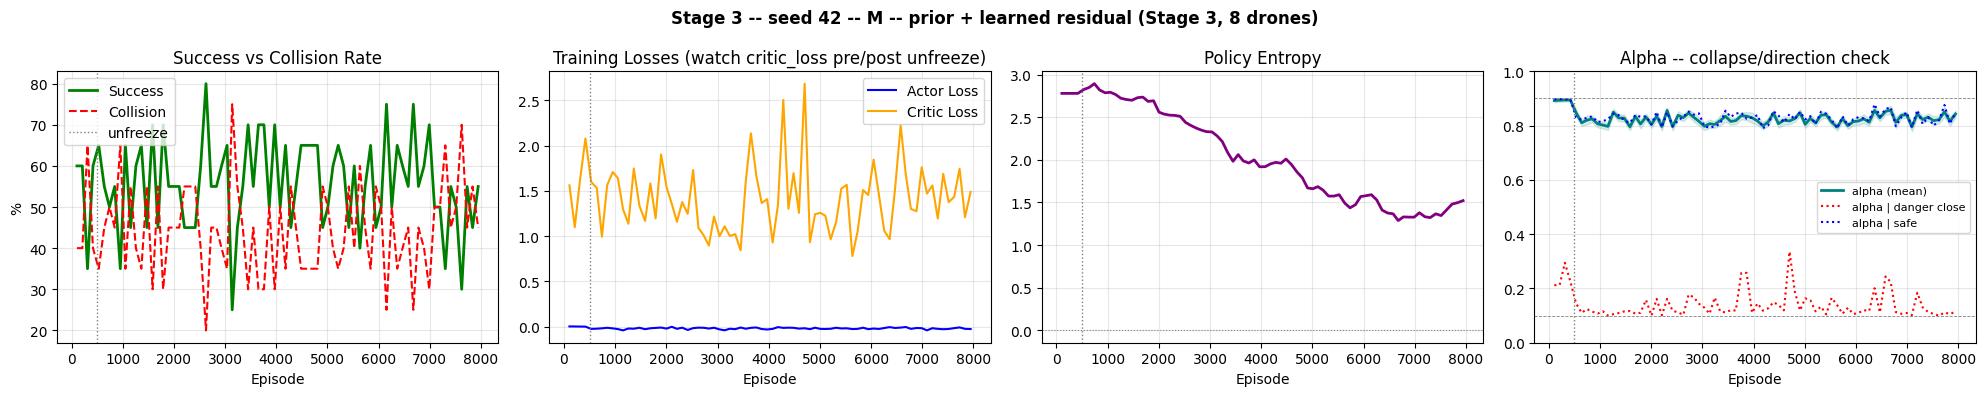

Plot saved for seed 42.

ALL 1 SEEDS DONE: [42]


In [6]:
# Cell 6 -- Train seed(s) with freeze-first critic warm-start + disjoint eval (Stage 3)
#
# NEW vs Stage 2 notebooks:
#   1. Freeze-first: actor + PAH start frozen (requires_grad=False), only
#      the critic trains, for the first CFG['freeze_episodes'] episodes.
#      Optimizer is critic-only during this window, then rebuilt with the
#      full param set (actor+critic+PAH) once unfrozen. See Cell 0 for why
#      PAH must freeze too, not just the actor.
#   2. Disjoint eval: eval_env is ALWAYS seeded with the fixed EVAL_SEED
#      (Cell 5), never the training seed -- see Cell 0.
# Otherwise reuses the Stage 2 training-loop pattern (per-drone
# rewards/log-probs, no averaging, last_eval/last_save so the modulo-skip
# bug can't recur -- see sessions/2026-09-16.md Parts 12-13).

import time, json as json_module

def make_env(seed, bonus=CFG['success_bonus']):
    return MultiUAVEnv(
        n_drones         = CFG['n_drones'],
        n_obstacles      = CFG['n_obstacles'],
        world_size       = CFG['world_size'],
        max_speed        = CFG['max_speed'],
        max_steps        = CFG['max_steps'],
        collision_radius = CFG['collision_radius'],
        target_radius    = CFG['target_radius'],
        success_bonus    = bonus,
        target_speed     = CFG['target_speed'],
        use_hungarian    = CFG['use_hungarian'],
        seed             = seed,
    )

# --- DIAGNOSTIC: obs range check before the whole loop starts ---
_diag_env = make_env(seed=SEEDS[0])
_diag_obs = _diag_env.reset()
print("[DIAG] obs min={:.4f}  max={:.4f}  shape={}".format(
    _diag_obs.min(), _diag_obs.max(), _diag_obs.shape))
assert _diag_obs.max() < 10.0, "STOP: obs unnormalized!"
assert _diag_obs.shape == (CFG['n_drones'], OBS_DIM), "STOP: obs shape doesn't match n_drones/OBS_DIM!"
print("[DIAG] obs range OK -- starting {}-seed loop\n".format(len(SEEDS)))
# -----------------------------------------------------------------

import matplotlib.pyplot as plt

def plot_results(history, results_dir, seed, freeze_episodes):
    """Per-seed results plot -- defined here (not a later cell) because
    run_training() below calls it immediately after each seed finishes, so
    the whole loop's progress is visible without waiting for all seeds."""
    n_panels = 4 if CFG['use_pah'] else 3
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
    mode_str = 'M -- prior + learned residual (Stage 3, 8 drones)' if CFG['use_pah'] else 'B4 -- fixed alpha = {} (Stage 3)'.format(CFG['fixed_alpha'])
    fig.suptitle('Stage 3 -- seed {} -- {}'.format(seed, mode_str), fontweight='bold')

    axes[0].plot(history['episode'], [s*100 for s in history['success']], color='green', linewidth=2, label='Success')
    axes[0].plot(history['episode'], [c*100 for c in history['collision']], 'r--', linewidth=1.5, label='Collision')
    axes[0].axvline(freeze_episodes, color='gray', linewidth=1, linestyle=':', label='unfreeze')
    axes[0].set_title('Success vs Collision Rate')
    axes[0].set_ylabel('%'); axes[0].set_xlabel('Episode')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['episode'], history['actor_loss'],  color='blue',   label='Actor Loss')
    axes[1].plot(history['episode'], history['critic_loss'], color='orange', label='Critic Loss')
    axes[1].axvline(freeze_episodes, color='gray', linewidth=1, linestyle=':')
    axes[1].set_title('Training Losses (watch critic_loss pre/post unfreeze)')
    axes[1].set_xlabel('Episode')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['episode'], history['entropy'], color='purple', linewidth=2)
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle=':')
    axes[2].axvline(freeze_episodes, color='gray', linewidth=1, linestyle=':')
    axes[2].set_title('Policy Entropy')
    axes[2].set_xlabel('Episode')
    axes[2].grid(True, alpha=0.3)

    if CFG['use_pah']:
        axes[3].plot(history['episode'], history['alpha_mean'], color='teal', linewidth=2, label='alpha (mean)')
        axes[3].fill_between(
            history['episode'],
            [m - s for m, s in zip(history['alpha_mean'], history['alpha_std'])],
            [m + s for m, s in zip(history['alpha_mean'], history['alpha_std'])],
            color='teal', alpha=0.15,
        )
        axes[3].plot(history['episode'], history['eval_alpha_low_tau'],  'r:', linewidth=1.5, label='alpha | danger close')
        axes[3].plot(history['episode'], history['eval_alpha_high_tau'], 'b:', linewidth=1.5, label='alpha | safe')
        axes[3].axvline(freeze_episodes, color='gray', linewidth=1, linestyle=':')
        axes[3].axhline(CFG['alpha_min'], color='gray', linewidth=0.6, linestyle='--')
        axes[3].axhline(CFG['alpha_max'], color='gray', linewidth=0.6, linestyle='--')
        axes[3].set_ylim(0, 1)
        axes[3].set_title('Alpha -- collapse/direction check')
        axes[3].set_xlabel('Episode')
        axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('{}/training_curves.png'.format(results_dir), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Plot saved for seed {}.'.format(seed))


def run_training(seed):
    print("\n" + "=" * 80)
    print("SEED {} -- {} -- STAGE 3 ({} drones)".format(seed, RUN_TAG, CFG['n_drones']))
    print("=" * 80)

    np.random.seed(seed)
    torch.manual_seed(seed)

    RESULTS_DIR = os.path.join(os.getcwd(), 'output-seed{}'.format(seed))
    os.makedirs(RESULTS_DIR, exist_ok=True)

    env      = make_env(seed=seed)
    eval_env = make_env(seed=EVAL_SEED, bonus=0.0)   # DISJOINT eval seed, not `seed`
    agent    = MAPPOAgent(
        n_drones        = CFG['n_drones'],
        obs_dim         = OBS_DIM,
        act_dim         = 2,
        use_pah         = CFG['use_pah'],
        fixed_alpha     = CFG['fixed_alpha'],
        alpha_min       = CFG['alpha_min'],
        alpha_max       = CFG['alpha_max'],
        pah_delta_scale = CFG['pah_delta_scale'],
        pah_prior_coef  = CFG['pah_prior_coef'],
        pah_horizon     = CFG['pah_horizon'],
        pah_d_max       = CFG['pah_d_max'],
        lr              = CFG['lr'],
        gamma           = CFG['gamma'],
        lam             = CFG['lam'],
        clip_eps        = CFG['clip_eps'],
        vf_coef         = CFG['vf_coef'],
        ent_coef        = CFG['ent_coef'],
        n_epochs        = CFG['n_epochs'],
        batch_size      = CFG['batch_size'],
    )

    agent.load_actor_only(_warm_path)
    print("Warm-started ACTOR ONLY from: {}".format(_warm_path))
    print("(critic starts fresh random -- 5-drone Stage 2b critic doesn't fit 8-drone joint state)")

    # --- FREEZE-FIRST: actor + PAH frozen, critic-only optimizer -------------
    freeze_episodes = CFG['freeze_episodes']
    for p in agent.actor.parameters():
        p.requires_grad = False
    if agent.use_pah:
        for p in agent.pah.parameters():
            p.requires_grad = False
    agent.opt = optim.Adam(list(agent.critic.parameters()), lr=CFG['lr'])
    unfrozen = (freeze_episodes <= 0)
    print("Freeze-first: actor{} frozen for the first {} episodes, critic-only optimizer.".format(
        " + PAH" if agent.use_pah else "", freeze_episodes))
    # ---------------------------------------------------------------------

    buffer   = RolloutBuffer(n_drones=CFG['n_drones'])
    history  = {
        'episode': [], 'success': [], 'collision': [],
        'actor_loss': [], 'critic_loss': [], 'entropy': [], 'log_std': [],
        'alpha_mean': [], 'alpha_std': [], 'pah_loss': [], 'delta_mean_abs': [],
        'eval_alpha_low_tau': [], 'eval_alpha_high_tau': [],
    }
    obs       = env.reset()
    ep_count  = 0
    last_eval = 0
    last_save = 0
    start     = time.time()

    header = " {:>9} | {:>8} | {:>10} | {:>8} | {:>8} | {:>10} | {:>7}".format(
        "Episode", "Success", "Collision", "A-Loss", "Entropy", "alpha(mu)", "Time"
    )
    print(header)
    print('-' * 75)

    while ep_count < CFG['total_episodes']:
        for _ in range(CFG['rollout_steps']):
            acts, lps, val = agent.get_actions(obs)
            next_obs, rews_env, terminated, truncated, info = env.step(acts)
            done = terminated or truncated

            r_mission  = info['r_mission']
            r_safety   = info['r_safety']
            pah_inputs = info['pah_inputs']

            alpha  = agent.compute_alpha(pah_inputs['tau'], pah_inputs['d_target'], pah_inputs['n_conflict'])
            rews   = alpha * r_mission + (1.0 - alpha) * r_safety

            buffer.add(obs, acts, rews, val, lps, done, r_mission, r_safety, pah_inputs)
            obs = next_obs
            if done:
                ep_count += 1
                obs = env.reset()

        # --- UNFREEZE once freeze_episodes reached ---------------------------
        if not unfrozen and ep_count >= freeze_episodes:
            for p in agent.actor.parameters():
                p.requires_grad = True
            if agent.use_pah:
                for p in agent.pah.parameters():
                    p.requires_grad = True
            full_params = list(agent.actor.parameters()) + list(agent.critic.parameters())
            if agent.use_pah:
                full_params += list(agent.pah.parameters())
            agent.opt = optim.Adam(full_params, lr=CFG['lr'])
            unfrozen = True
            print("  >> UNFROZEN at ep{}: actor{} now training jointly with critic.".format(
                ep_count, " + PAH" if agent.use_pah else ""))
        # -----------------------------------------------------------------

        stats = agent.update(buffer, obs)
        a_loss, v_loss, entropy = stats['actor_loss'], stats['critic_loss'], stats['entropy']
        buffer.clear()

        if ep_count >= last_eval + CFG['eval_every']:
            successes, collisions = 0, 0
            eval_alphas, eval_taus = [], []
            for _ in range(CFG['eval_episodes']):
                o    = eval_env.reset()
                done = False
                while not done:
                    a, _, _ = agent.get_actions(o)
                    o, _, terminated, truncated, info = eval_env.step(a)
                    done = terminated or truncated
                    pi = info['pah_inputs']
                    al = agent.compute_alpha(pi['tau'], pi['d_target'], pi['n_conflict'])
                    eval_alphas.append(al)
                    eval_taus.append(pi['tau'])
                if info['all_targets_reached'] and not info['episode_collision']:
                    successes += 1
                if info['episode_collision']:
                    collisions += 1

            sr      = successes  / CFG['eval_episodes']
            cr      = collisions / CFG['eval_episodes']
            elapsed = (time.time() - start) / 60
            log_std = agent.actor.log_std.data.cpu().numpy()

            eval_alphas  = np.concatenate(eval_alphas)
            eval_taus    = np.concatenate(eval_taus)
            danger_mask  = eval_taus <= (CFG['pah_horizon'] * 0.34)
            safe_mask    = eval_taus >= (CFG['pah_horizon'] * 0.9)
            alpha_low_tau  = float(eval_alphas[danger_mask].mean()) if danger_mask.any() else float('nan')
            alpha_high_tau = float(eval_alphas[safe_mask].mean())   if safe_mask.any()   else float('nan')

            print(" {:>9} | {:>7.1%} | {:>9.1%} | {:>+8.4f} | {:>8.4f} | {:>10.3f} | {:>6.1f}m".format(
                ep_count, sr, cr, a_loss, entropy, stats['alpha_mean'], elapsed
            ))
            last_eval = ep_count

            history['episode'].append(ep_count)
            history['success'].append(sr)
            history['collision'].append(cr)
            history['actor_loss'].append(a_loss)
            history['critic_loss'].append(v_loss)
            history['entropy'].append(entropy)
            history['log_std'].append(log_std.tolist())
            history['alpha_mean'].append(stats['alpha_mean'])
            history['alpha_std'].append(stats['alpha_std'])
            history['pah_loss'].append(stats.get('pah_loss'))
            history['delta_mean_abs'].append(stats.get('delta_mean_abs'))
            history['eval_alpha_low_tau'].append(alpha_low_tau)
            history['eval_alpha_high_tau'].append(alpha_high_tau)

        if ep_count >= last_save + CFG['save_every']:
            agent.save("{}/checkpoint_ep{}.pt".format(RESULTS_DIR, ep_count))
            last_save = ep_count
            print("  >> checkpoint saved: ep{}".format(ep_count))

    agent.save('{}/final_model.pt'.format(RESULTS_DIR))
    with open('{}/history.json'.format(RESULTS_DIR), 'w') as f:
        json_module.dump(history, f, indent=2)

    total_min = (time.time() - start) / 60
    print('\nSeed {} done in {:.1f}m. Saved to {}'.format(seed, total_min, RESULTS_DIR))

    if CFG['use_pah']:
        _hi, _lo = history['eval_alpha_high_tau'][-1], history['eval_alpha_low_tau'][-1]
        if not (np.isnan(_hi) or np.isnan(_lo)):
            print('Final alpha(safe) - alpha(danger) = {:+.3f}'.format(_hi - _lo))

    plot_results(history, RESULTS_DIR, seed, freeze_episodes)
    return history


all_histories = {}
for _seed in SEEDS:
    all_histories[_seed] = run_training(_seed)

print("\n" + "=" * 80)
print("ALL {} SEEDS DONE: {}".format(len(SEEDS), SEEDS))
print("=" * 80)


In [7]:
# Cell 7 — Combined summary across all 5 seeds

def summarize(history):
    n = len(history['episode'])
    avg_s = sum(history['success']) / n * 100
    avg_c = sum(history['collision']) / n * 100
    third = max(n // 3, 1)
    ft_s  = sum(history['success'][:third]) / third * 100
    lt_s  = sum(history['success'][n-third:]) / third * 100
    ent0, ent1 = history['entropy'][0], history['entropy'][-1]

    right = wrong = 0
    ht_map = dict(zip(history['episode'], history['eval_alpha_high_tau']))
    for e, lv in zip(history['episode'], history['eval_alpha_low_tau']):
        if lv != lv:  # nan
            continue
        hv = ht_map.get(e, float('nan'))
        if hv != hv:
            continue
        if lv >= hv:
            wrong += 1
        else:
            right += 1

    return dict(avg_s=avg_s, avg_c=avg_c, ft_s=ft_s, lt_s=lt_s,
                ent0=ent0, ent1=ent1, right=right, wrong=wrong)


print(" {:>6} | {:>8} | {:>10} | {:>14} | {:>14} | {:>14}".format(
    "Seed", "Avg Succ", "Avg Coll", "First->Last %", "Entropy end", "Direction (r/w)"
))
print('-' * 90)

tot_right = tot_wrong = 0
sum_s = sum_c = 0.0
for _seed in SEEDS:
    stats = summarize(all_histories[_seed])
    tot_right += stats['right']
    tot_wrong += stats['wrong']
    sum_s += stats['avg_s']
    sum_c += stats['avg_c']
    dir_str = '{}/{}'.format(stats['right'], stats['right'] + stats['wrong']) if CFG['use_pah'] else 'n/a (fixed)'
    print(" {:>6} | {:>7.1f}% | {:>9.1f}% | {:>6.1f}->{:<6.1f} | {:>14.3f} | {:>14}".format(
        _seed, stats['avg_s'], stats['avg_c'], stats['ft_s'], stats['lt_s'], stats['ent1'], dir_str
    ))

print('-' * 90)
print(" {:>6} | {:>7.1f}% | {:>9.1f}% |".format('AVG', sum_s / len(SEEDS), sum_c / len(SEEDS)))

if CFG['use_pah'] and (tot_right + tot_wrong) > 0:
    pct_wrong = 100 * tot_wrong / (tot_right + tot_wrong)
    print("\nCombined direction check across all {} seeds: {}/{} right, {}/{} wrong ({:.0f}%)".format(
        len(SEEDS), tot_right, tot_right + tot_wrong, tot_wrong, tot_right + tot_wrong, pct_wrong
    ))
    print("Compare avg success/collision above to Stage 3 Hungarian ON (ADOPTED): 74.8%/25.2%, single seed (sessions/2026-09-19.md Section 11).")
    print("Compare to the Stage 2 version of this same ablation: code/notebooks/v3/stage2/ablation-hungarian/.")
    print("Compare to Stage 1's ablation (3 drones, no PAH): ON 100%/0%, OFF 96.3%/3.6% avg, 54% of checkpoints had collisions.")
    print("Compare to DA-MAPPO's own ablation (bin/91, Table VI): their success dropped to 0% with assignment removed.")
    print("If this Stage 3 drop is proportionally bigger than Stage 2's, that supports 'more drones -> assignment matters more' (docs/research/07_literature_comparison.md).")
    print("This design (prior+residual) should structurally never lock into a uniformly wrong direction -- alpha_safe(tau) is hardcoded, not learned.")
    print("Check delta_mean_abs in each seed's history.json too -- if it stays near 0, the learned residual added nothing beyond alpha_safe(tau) alone (see docs/research/06_pah_validation_preregistration.md).")

import json as json_module
with open('combined_summary.json', 'w') as f:
    json_module.dump({
        str(_seed): summarize(all_histories[_seed]) for _seed in SEEDS
    }, f, indent=2)
print("\nSaved combined_summary.json")


   Seed | Avg Succ |   Avg Coll |  First->Last % |    Entropy end | Direction (r/w)
------------------------------------------------------------------------------------------
     42 |    55.7% |      44.3% |   55.2->54.0   |          1.522 |          76/76
------------------------------------------------------------------------------------------
    AVG |    55.7% |      44.3% |

Combined direction check across all 1 seeds: 76/76 right, 0/76 wrong (0%)
Compare avg success/collision above to Stage 3 Hungarian ON (ADOPTED): 74.8%/25.2%, single seed (sessions/2026-09-19.md Section 11).
Compare to the Stage 2 version of this same ablation: code/notebooks/v3/stage2/ablation-hungarian/.
Compare to Stage 1's ablation (3 drones, no PAH): ON 100%/0%, OFF 96.3%/3.6% avg, 54% of checkpoints had collisions.
Compare to DA-MAPPO's own ablation (bin/91, Table VI): their success dropped to 0% with assignment removed.
If this Stage 3 drop is proportionally bigger than Stage 2's, that supports 'more dr